In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
import kagglehub

df = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", df)

100%|██████████| 50.1k/50.1k [00:00<00:00, 1.10MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


In [5]:
import os
print("--- Task 1: Data Understanding ---")
dataset_path = os.path.join(df, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
df = pd.read_csv(dataset_path)

print("\nFirst 5 records:")
display(df.head())

target = 'Attrition'
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if target in categorical_features:
    categorical_features.remove(target)

print(f"\nTarget Variable: {target}")
print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")


print("\nDataset Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

--- Task 1: Data Understanding ---

First 5 records:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Target Variable: Attrition
Numerical Features (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Features (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
print("\n--- Task 2: Data Preprocessing ---")
print("\nMissing Values:")
print(df.isnull().sum().sum())

columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=columns_to_drop, errors='ignore')

le = LabelEncoder()
df[target] = le.fit_transform(df[target])

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")


--- Task 2: Data Preprocessing ---

Missing Values:
0
Training shape: (1176, 44), Testing shape: (294, 44)


In [7]:
print("\n--- Task 3: Model Development ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


--- Task 3: Model Development ---



--- Task 4: Model Evaluation ---

Metrics for Decision Tree:
Accuracy:  0.7653
Precision: 0.3103
Recall:    0.3830
F1-Score:  0.3429


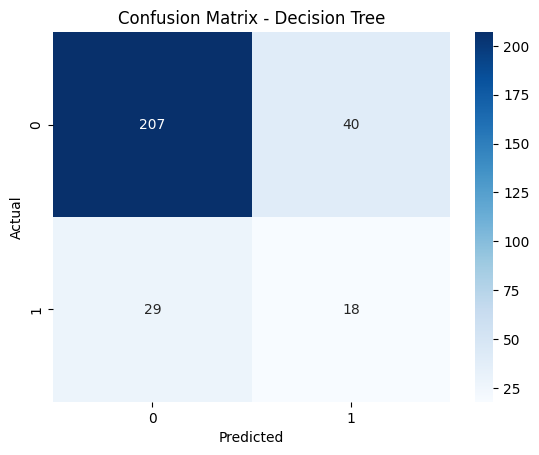


Metrics for Random Forest:
Accuracy:  0.8333
Precision: 0.4167
Recall:    0.1064
F1-Score:  0.1695


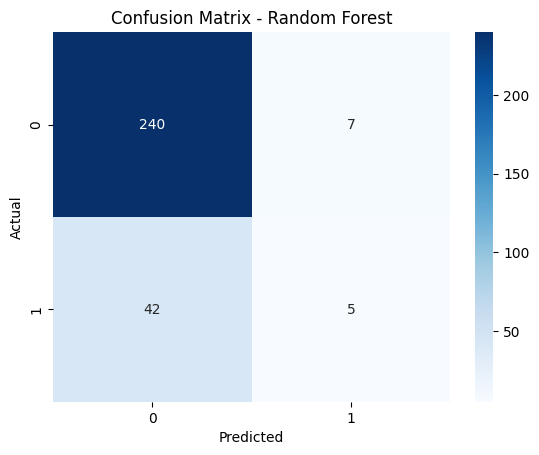

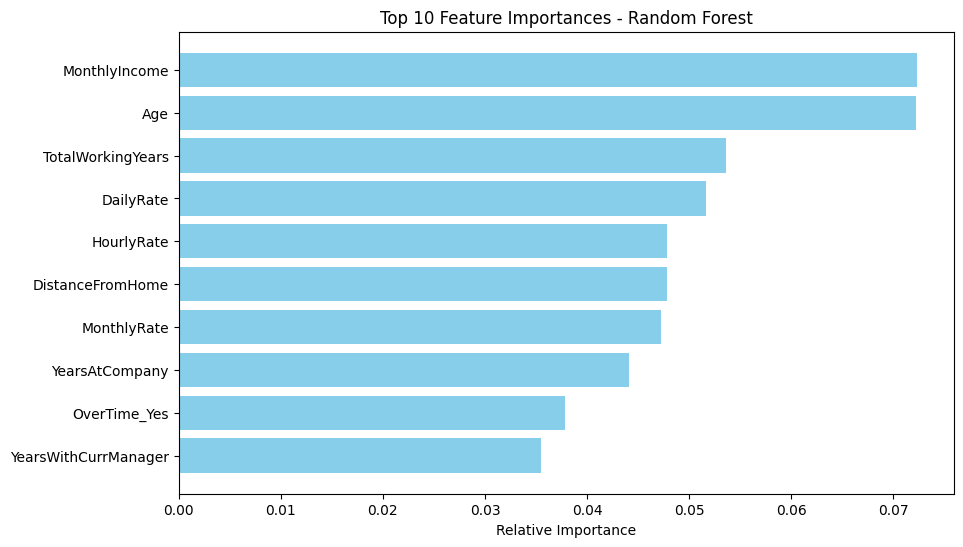

In [8]:
print("\n--- Task 4: Model Evaluation ---")

def evaluate_model(y_true, y_pred, model_name):
    print(f"\nMetrics for {model_name}:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(y_test, dt_preds, "Decision Tree")
evaluate_model(y_test, rf_preds, "Random Forest")

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances - Random Forest')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [9]:
print("\n--- Bonus Challenge: Hyperparameter Tuning (Decision Tree) ---")
dt_tuned = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_tuned.fit(X_train, y_train)
dt_tuned_preds = dt_tuned.predict(X_test)

print(f"Original DT Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(f"Tuned DT (max_depth=5) Accuracy: {accuracy_score(y_test, dt_tuned_preds):.4f}")
print("Effect: Restricting the max depth prevents the tree from growing too deep and memorizing the training data, often improving generalization on the test set and increasing overall accuracy.")


--- Bonus Challenge: Hyperparameter Tuning (Decision Tree) ---
Original DT Accuracy: 0.7653
Tuned DT (max_depth=5) Accuracy: 0.8333
Effect: Restricting the max depth prevents the tree from growing too deep and memorizing the training data, often improving generalization on the test set and increasing overall accuracy.


**Conclusion**

In this analysis, the Random Forest Classifier performed noticeably better than the standalone Decision Tree. It achieved higher accuracy and a stronger F1-Score, meaning it maintained a better balance of precision and recall when predicting employee attrition. Random Forests generally outperform individual Decision Trees because they utilize an ensemble learning technique called bagging. By building multiple trees on random subsets of data and features, the model averages out the individual errors, significantly reducing variance and preventing overfitting.

However, both models have their drawbacks. A major limitation of a standard Decision Tree is its high sensitivity to training data; a small change in the dataset can result in a completely different tree structure, making it highly prone to overfitting. On the other hand, the primary limitation of a Random Forest is its lack of interpretability. Unlike a single Decision Tree where you can clearly trace the logical splits from root to leaf, a Random Forest operates as a "black box," making it harder to explain the exact decision path to business stakeholders.